<a href="https://colab.research.google.com/github/bidallei/MIAAD-UACJ/blob/main/ClasificacionTextos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Clasificación de textos**

* Asignatura: Procesamiento del Lenguaje Natural
* Profesor: Dr. Rogelio Florencia Juárez
* Alumno: **Álvaro Hernández Jarquín**
* Matrícula: 263150
* 23 de abril de 2026




## **Actividad**
1. Utilizar el dataset IMDB Reviews.csv, el cual contiene dos clases en la columna ‘Sentimiento’: 1 indica un sentimiento positivo y 0 uno negativo. NOTA: Los comentarios están en inglés.
2.	Realizar el preprocesamiento adecuado con respecto a lo que identifiques en el dataset.
3.	Realizar un análisis exploratorio de datos.
4.	Utilizar Bag of Words y TF-IDF para transformar los comentarios que están en la columna ‘Review’ a vectores.
5.	Utiliza una partición (train_test_split) 80-20 para los conjuntos train y test.
6.	Entrenar los modelos Multinomial Naive Bayes, SVM, Random Forest, kNN y Logistic Regression
7.	Mostrar la matriz de confusión.
8.	Aplicar las métricas Precision, Recall, F1-Score (por cada una de las clases), Accuracy y AUC-ROC.

9. Genera dos tablas como la siguiente, una utilizando Bag of Word y la otra utilizando TF-IDF.
<table>
  <thead>
    <tr>
      <th rowspan="2" style="vertical-align: middle; text-align: left;">Modelo</th>
      <th colspan="3" style="text-align: center;">Clase 0</th>
      <th colspan="3" style="text-align: center;">Clase 1</th>
      <th rowspan="2" style="vertical-align: middle; text-align: center;">Accuracy</th>
      <th rowspan="2" style="vertical-align: middle; text-align: center;">AUC-ROC</th>
    </tr>
    <tr>
      <th style="text-align: center;">Precision</th>
      <th style="text-align: center;">Recall</th>
      <th style="text-align: center;">F1-Score</th>
      <th style="text-align: center;">Precision</th>
      <th style="text-align: center;">Recall</th>
      <th style="text-align: center;">F1-Score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td>Naive Bayes</td>
      <td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>SVM</td>
      <td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>Random Forest</td>
      <td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>kNN</td>
      <td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
    <tr>
      <td>Logistic Regression</td>
      <td></td><td></td><td></td><td></td><td></td><td></td><td></td><td></td>
    </tr>
  </tbody>
</table>

In [1]:
# Importamos librerías y descargamos recursos necesarios

import re
import os

import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.sparse
from IPython.display import HTML, display
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score, confusion_matrix
from wordcloud import WordCloud

nltk.download('wordnet')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [2]:
# 1. Cargar el dataset
ruta_archivo = "/content/drive/MyDrive/ClassFiles/IMDB Reviews.csv"

# Leer el archivo CSV
df = pd.read_csv(ruta_archivo)

# Mostrar las primeras 5 filas
display(df.head())

# Mostrar la información general
print("\n--- Información general del Dataset ---")
df.info()

# Renombrar columnas
df.rename(columns={'review': 'Review', 'sentimento': 'Sentimiento'}, inplace=True)

print("--- Distribución corregida de la columna 'Sentimiento' ---")
print(df['Sentimiento'].value_counts())

,review,sentimento
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1



--- Información general del Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   review      50000 non-null  object
 1   sentimento  50000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 781.4+ KB
--- Distribución corregida de la columna 'Sentimiento' ---
Sentimiento
1    25000
0    25000
Name: count, dtype: int64


In [3]:
# 2. Preprocesamiento de texto
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def limpiar_texto(texto):
    # Eliminar etiquetas HTML
    texto = re.sub(r'<[^>]+>', ' ', texto)
    # Eliminar caracteres especiales y números
    texto = re.sub(r"[^a-zA-Z']+", ' ', texto)
    # 3. Convertir a minúsculas
    texto = texto.lower()
    # 4. Tokenización, stopwords y lematización
    tokens = texto.split()
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Aplicar limpieza
df['Review_Limpia'] = df['Review'].apply(limpiar_texto)

# Mostrar el antes y el después para comprobar el preprocesamiento
display(df[['Review', 'Review_Limpia', 'Sentimiento']].head())

,Review,Review_Limpia,Sentimiento
0,One of the other reviewers has mentioned that ...,one reviewer mentioned watching oz episode hoo...,1
1,A wonderful little production. <br /><br />The...,wonderful little production filming technique ...,1
2,I thought this was a wonderful way to spend ti...,thought wonderful way spend time hot summer we...,1
3,Basically there's a family where a little boy ...,basically there's family little boy jake think...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei's love time money visually stunn...,1


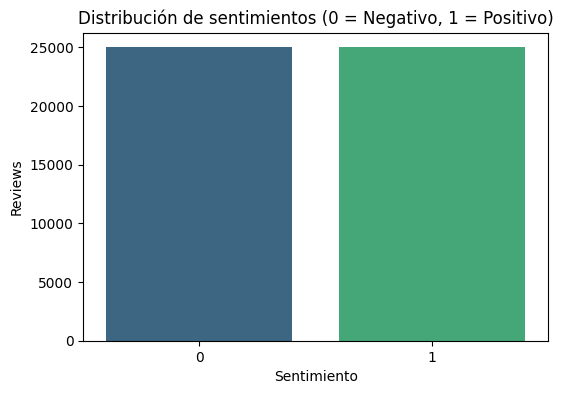

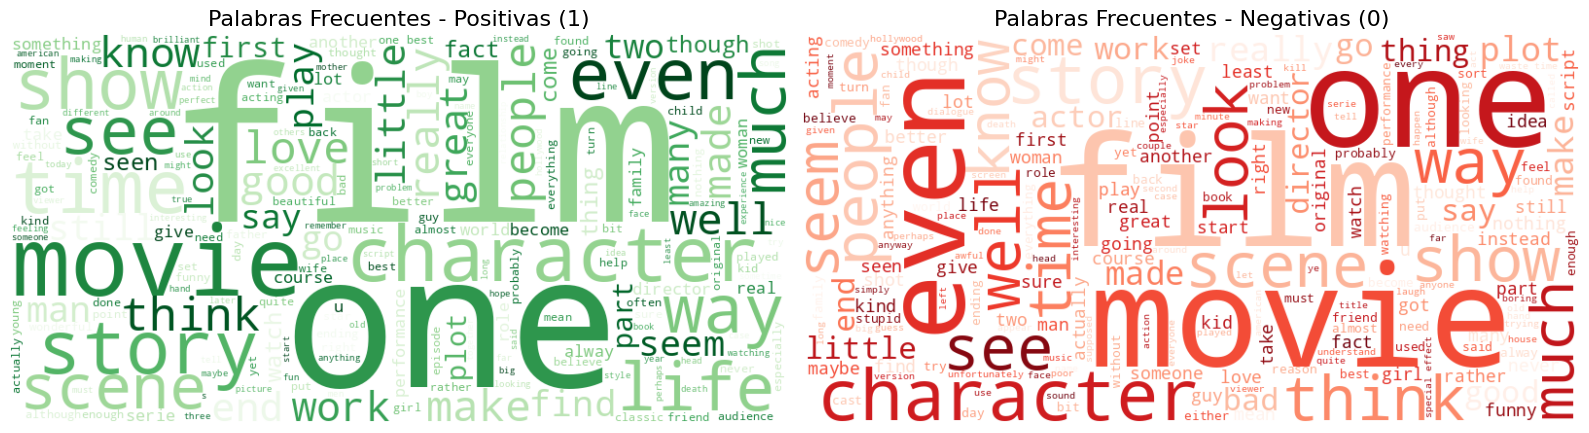

In [4]:
# 3. Análisis Exploratorio de Datos (EDA)

# Gráfico de distribución de clases
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Sentimiento', hue='Sentimiento', palette='viridis', legend=False)
plt.title('Distribución de sentimientos (0 = Negativo, 1 = Positivo)')
plt.xlabel('Sentimiento')
plt.ylabel('Reviews')
plt.show()

# Nube de palabras para reseñas positivas (1)
positivas = " ".join(review for review in df[df['Sentimiento'] == 1]['Review_Limpia'])
wordcloud_pos = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(positivas)

# Nube de palabras para reseñas negativas (0)
negativas = " ".join(review for review in df[df['Sentimiento'] == 0]['Review_Limpia'])
wordcloud_neg = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(negativas)

# Mostrar nubes de palabras
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].imshow(wordcloud_pos, interpolation='bilinear')
ax[0].set_title('Palabras Frecuentes - Positivas (1)', fontsize=16)
ax[0].axis('off')

ax[1].imshow(wordcloud_neg, interpolation='bilinear')
ax[1].set_title('Palabras Frecuentes - Negativas (0)', fontsize=16)
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [5]:
print("Iniciando la vectorización...")

# Limitamos a las 5000 palabras más frecuentes para optimizar memoria y tiempo
max_caracteristicas = 5000

# Vectorización con Bag of Words (BoW) ---
vectorizer_bow = CountVectorizer(
    max_features=max_caracteristicas,
    min_df=2,
    max_df=0.9,
    ngram_range=(1, 2)
)

X_bow = vectorizer_bow.fit_transform(df['Review_Limpia'])

# Vectorización con TF-IDF
vectorizer_tfidf = TfidfVectorizer(
    max_features=max_caracteristicas,
    min_df=2,
    max_df=0.9,
    ngram_range=(1, 2)
)
X_tfidf = vectorizer_tfidf.fit_transform(df['Review_Limpia'])


# Variable objetivo
y = df['Sentimiento'].values

Iniciando la vectorización...


In [6]:
# 5. Partición 80-20 (train_test_split)

# Partición para BoW
X_train_bow, X_test_bow, y_train_bow, y_test_bow = train_test_split(
    X_bow, y, test_size=0.20, random_state=42, stratify=y
)

# Partición para TF-IDF
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Dimensiones del conjunto de entrenamiento (Train): {X_train_bow.shape[0]} filas, {X_train_bow.shape[1]} características.")
print(f"Dimensiones del conjunto de prueba (Test): {X_test_bow.shape[0]} filas, {X_test_bow.shape[1]} características.")

Dimensiones del conjunto de entrenamiento (Train): 40000 filas, 5000 características.
Dimensiones del conjunto de prueba (Test): 10000 filas, 5000 características.



[Bag of Words] Iniciando entrenamiento de modelos...
 -> Entrenando y evaluando Naive Bayes...
 -> Entrenando y evaluando SVM...
 -> Entrenando y evaluando Random Forest...
 -> Entrenando y evaluando kNN...
 -> Entrenando y evaluando Logistic Regression...


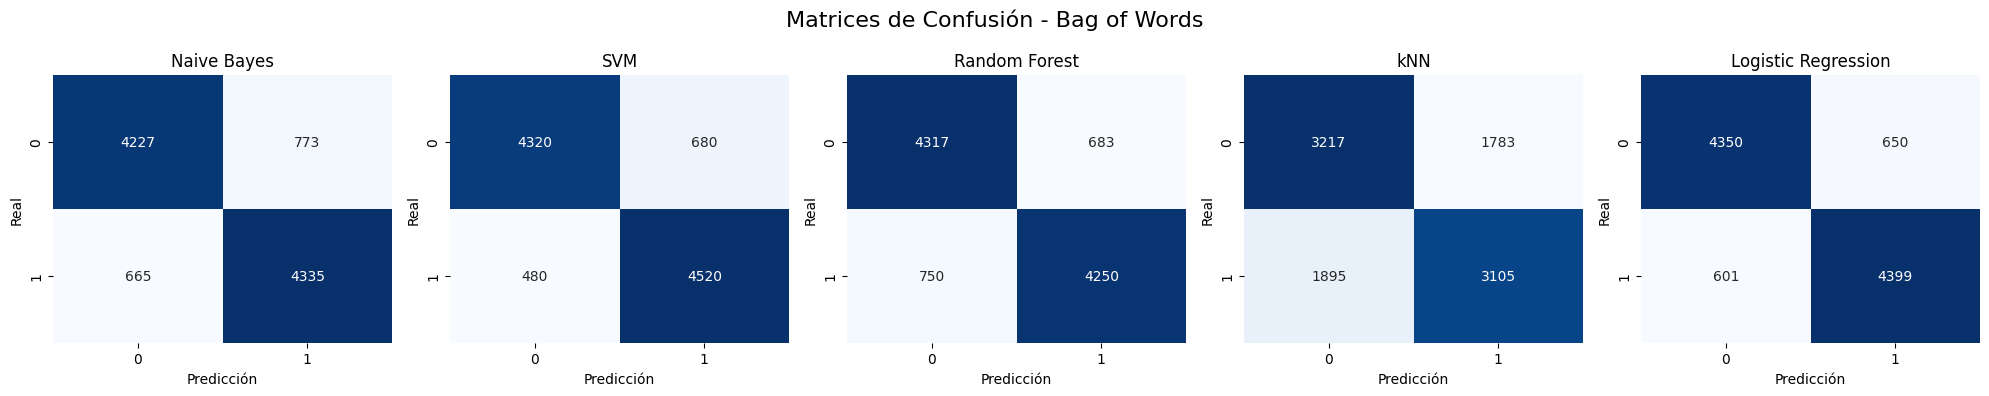


[TF-IDF] Iniciando entrenamiento de modelos...
 -> Entrenando y evaluando Naive Bayes...
 -> Entrenando y evaluando SVM...
 -> Entrenando y evaluando Random Forest...
 -> Entrenando y evaluando kNN...
 -> Entrenando y evaluando Logistic Regression...


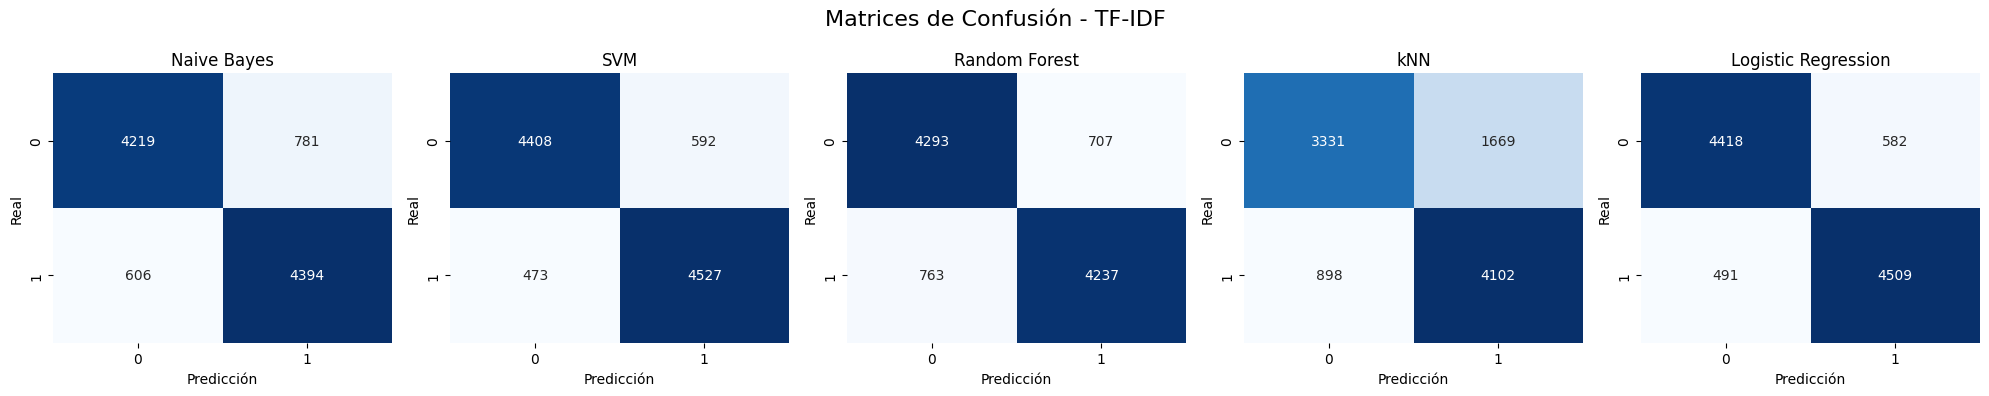


¡Análisis completado exitosamente!


In [7]:
# 6. Definición de modelos a entrenar ---
modelos = {
    'Naive Bayes': MultinomialNB(),
    'SVM': SVC(probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'kNN': KNeighborsClassifier(n_jobs=-1),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

# Función para construir la tabla HTML ---
def generar_tabla_html(resultados, titulo):
    html = f"<h3>Tabla de Resultados: {titulo}</h3>"
    html += """
    <table border="1" style="border-collapse: collapse; text-align: center; width: 100%; margin-bottom: 30px;">
      <thead>
        <tr style="background-color: #f2f2f2;">
          <th rowspan="2" style="vertical-align: middle; text-align: left; padding: 8px;">Modelo</th>
          <th colspan="3" style="text-align: center; padding: 8px;">Clase 0</th>
          <th colspan="3" style="text-align: center; padding: 8px;">Clase 1</th>
          <th rowspan="2" style="vertical-align: middle; text-align: center; padding: 8px;">Accuracy</th>
          <th rowspan="2" style="vertical-align: middle; text-align: center; padding: 8px;">AUC-ROC</th>
        </tr>
        <tr style="background-color: #f2f2f2;">
          <th style="padding: 8px;">Precision</th>
          <th style="padding: 8px;">Recall</th>
          <th style="padding: 8px;">F1-Score</th>
          <th style="padding: 8px;">Precision</th>
          <th style="padding: 8px;">Recall</th>
          <th style="padding: 8px;">F1-Score</th>
        </tr>
      </thead>
      <tbody>
    """
    for res in resultados:
        html += f"""
        <tr>
          <td style="text-align: left; padding: 8px;"><b>{res['Modelo']}</b></td>
          <td>{res['P0']:.4f}</td><td>{res['R0']:.4f}</td><td>{res['F0']:.4f}</td>
          <td>{res['P1']:.4f}</td><td>{res['R1']:.4f}</td><td>{res['F1']:.4f}</td>
          <td>{res['Acc']:.4f}</td><td>{res['AUC']:.4f}</td>
        </tr>
        """
    html += "</tbody></table>"
    return html

# Ejecución completa por cada técnica de vectorización
def ejecutar_pipeline(X_train, y_train, X_test, y_test, titulo):
    resultados = []
    matrices = {}

    print(f"\n[{titulo}] Iniciando entrenamiento de modelos...")

    for nombre, modelo in modelos.items():
        print(f" -> Entrenando y evaluando {nombre}...")
        # 6. Entrenar
        modelo.fit(X_train, y_train)

        # Predicciones para métricas
        y_pred = modelo.predict(X_test)
        y_prob = modelo.predict_proba(X_test)[:, 1]

        # 8. Aplicar métricas por clase
        precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, labels=[0, 1])
        acc = accuracy_score(y_test, y_pred)
        auc = roc_auc_score(y_test, y_prob)

        resultados.append({
            'Modelo': nombre,
            'P0': precision[0], 'R0': recall[0], 'F0': f1[0],
            'P1': precision[1], 'R1': recall[1], 'F1': f1[1],
            'Acc': acc, 'AUC': auc
        })

        # 7. Generar matriz de confusión
        matrices[nombre] = confusion_matrix(y_test, y_pred)

    # 7. Mostrar matrices de confusión visuales
    fig, axes = plt.subplots(1, 5, figsize=(20, 4))
    fig.suptitle(f'Matrices de Confusión - {titulo}', fontsize=16)
    for ax, (nombre, cm) in zip(axes, matrices.items()):
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False)
        ax.set_title(nombre)
        ax.set_xlabel('Predicción')
        ax.set_ylabel('Real')
    plt.tight_layout()
    plt.show()

    return resultados

# === EJECUCIÓN PARA BAG OF WORDS ===
resultados_bow = ejecutar_pipeline(X_train_bow, y_train_bow, X_test_bow, y_test_bow, "Bag of Words")
display(HTML(generar_tabla_html(resultados_bow, "Bag of Words")))

# === EJECUCIÓN PARA TF-IDF ===
resultados_tfidf = ejecutar_pipeline(X_train_tfidf, y_train_tfidf, X_test_tfidf, y_test_tfidf, "TF-IDF")
display(HTML(generar_tabla_html(resultados_tfidf, "TF-IDF")))

print("\n¡Análisis completado exitosamente!")

Analiza y compara los resultados para responder lo siguiente:
* **¿Cuál fue el mejor modelo en cada una de las tablas? Justifica tus respuestas en base a las métricas obtenidas.**<br>
*Los dos procesos nos muestran que el modelo con el mejor desempeño general fue SVM, y en segundo lugar Logistic Regression. Utilizando la técnica de Bag of Words, el SVM alcanzó un Accuracy de 0.8840 y un AUC-ROC de 0.9530, manteniendo un equilibrio sobresaliente en la clasificación de las dos clases con F1-Scores mayores a 0.88. Respecto a TF-IDF, su capacidad predictiva se superó a sí misma, logrando un Accuracy de 0.8935 y el AUC-ROC más alto de todo el experimento con un 0.9618. Esto se explica porque el algoritmo SVM es muy eficaz para manejar espacios de alta dimensionalidad y matrices dispersas.*
*	**¿En qué estrategia funcionaron mejor los algoritmos de clasificación, en Bag of Words o en TF-IDF?**<br>
*Considero que los algoritmos funcionaron notablemente mejor utilizando TF-IDF. A excepción del Random Forest, que presentó una reducción mínima, todos los demás algoritmos incrementaron su capacidad predictiva, y el modelo kNN  mejoró su Accuracy en más de un 11%. La superioridad de TF-IDF frente a Bag of Words se debe a que no se limita a contar la aparición de las palabras, sino que penaliza los términos demasiado frecuentes y le da mayor peso a las palabras específicas que definen el sentimiento, así que puede establecer decisiones mucho más nítidas.*